<a href="https://colab.research.google.com/github/Joey-Jireh/eye-of-ra/blob/main/notebooks/week2/week2_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — Week 2 Header & Library Imports
# Eye of Ra 👁️ — Week 2: Feature Engineering & Model Training

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("✅ Libraries loaded — Week 2 begins")
print("👁️ Eye of Ra — Feature Engineering & Model Training")

# Git: Cell 1 — Week 2 header and imports

✅ Libraries loaded — Week 2 begins
👁️ Eye of Ra — Feature Engineering & Model Training


In [ ]:
# Cell 2 — Load master dataset
df = pd.read_csv('/content/eye_of_ra_master_dataset_v3.csv')

print("=" * 50)
print("👁️ EYE OF RA — MASTER DATASET LOADED")
print("=" * 50)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFraud labels:   {df['fraud_label'].sum()}")
print(f"Audit flagged:  {df['audit_flagged'].sum()}")
print(f"Clean:          {(df['fraud_label'] == 0).sum()}")
print(f"Fraud rate:     {df['fraud_label'].mean()*100:.1f}%")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Git: Cell 2 — reload master dataset for Week 2

👁️ EYE OF RA — MASTER DATASET LOADED
Shape: 262 rows x 16 columns

Columns: ['year', 'contract_id', 'entity', 'contract_description', 'investigation_result', 'decision', 'fraud_label', 'supplier', 'is_variation', 'is_sole_source', 'entity_frequency', 'supplier_frequency', 'repeat_supplier', 'entity_standard', 'audit_flagged', 'audit_flag_count']

Fraud labels:   23
Audit flagged:  35
Clean:          239
Fraud rate:     8.8%

Missing values:
year                    0
contract_id             0
entity                  0
contract_description    0
investigation_result    4
decision                4
fraud_label             0
supplier                0
is_variation            0
is_sole_source          0
entity_frequency        0
supplier_frequency      0
repeat_supplier         0
entity_standard         0
audit_flagged           0
audit_flag_count        0
dtype: int64


In [ ]:
# Cell 3 — Feature 1: Award Concentration Score
# How dominant is one supplier within an entity?
# High concentration = one supplier winning most contracts = red flag

# Step 1: Count contracts per entity-supplier pair
entity_supplier_counts = df.groupby(['entity_standard', 'supplier']).size().reset_index(name='pair_count')

# Step 2: Total contracts per entity
entity_totals = df.groupby('entity_standard').size().reset_index(name='entity_total')

# Step 3: Merge and compute concentration ratio
concentration = entity_supplier_counts.merge(entity_totals, on='entity_standard')
concentration['award_concentration'] = concentration['pair_count'] / concentration['entity_total']

# Step 4: Map back to main dataframe
df = df.merge(concentration[['entity_standard', 'supplier', 'award_concentration']],
              on=['entity_standard', 'supplier'], how='left')

# Step 5: Review
print("=" * 50)
print("✅ FEATURE 1: Award Concentration Score")
print("=" * 50)
print(f"Range: {df['award_concentration'].min():.3f} — {df['award_concentration'].max():.3f}")
print(f"Mean:  {df['award_concentration'].mean():.3f}")
print(f"\nTop 10 highest concentration contracts:")
print(df[['entity_standard', 'supplier', 'award_concentration', 'fraud_label']]
      .sort_values('award_concentration', ascending=False).head(10).to_string())

# Git: Cell 3 — Feature 1: award concentration score

✅ FEATURE 1: Award Concentration Score
Range: 0.062 — 1.000
Mean:  0.580

Top 10 highest concentration contracts:
                              entity_standard                                  supplier  award_concentration  fraud_label
261  Ghana Geological Survey Authority (GGSA)                   Messrs. Forte Logistics                1.000            0
260            Ghana Maritime Authority (GMA)                Messrs. Kaysens Gaisie Ltd                1.000            0
259  Ghana Export Promotion Authority (GEPA))       Messrs. Insight Advertising Limited                1.000            0
243       National Blood Service Ghana (NBSG)  Messrs. Investrade International Co. Ltd                1.000            0
241        Kumasi Metropolitan Assembly (KMA)                                   Unknown                1.000            0
236            Ghana Commodity Exchange (GCX)                         Messrs. DESS Inc.                1.000            0
240        Centre for Plant Medi

In [ ]:
# Cell 4 — Feature 2: Method Abuse Score
# Sole-source frequency per entity — entities that repeatedly bypass competitive bidding

# Step 1: Sole source rate per entity
sole_source_rate = df.groupby('entity_standard').agg(
    total_contracts=('contract_id', 'count'),
    sole_source_count=('is_sole_source', 'sum')
).reset_index()

sole_source_rate['method_abuse_score'] = (
    sole_source_rate['sole_source_count'] / sole_source_rate['total_contracts']
)

# Step 2: Map back
df = df.merge(sole_source_rate[['entity_standard', 'method_abuse_score']],
              on='entity_standard', how='left')

# Step 3: Check correlation with fraud
print("=" * 50)
print("✅ FEATURE 2: Method Abuse Score")
print("=" * 50)
print(f"Range: {df['method_abuse_score'].min():.3f} — {df['method_abuse_score'].max():.3f}")
print(f"Mean:  {df['method_abuse_score'].mean():.3f}")

print(f"\nMethod abuse score — fraud vs clean:")
print(df.groupby('fraud_label')['method_abuse_score'].describe().round(3))

print(f"\nTop 10 most abusive entities:")
top_abuse = sole_source_rate.sort_values('method_abuse_score', ascending=False).head(10)
print(top_abuse.to_string())

# Git: Cell 4 — Feature 2: method abuse score

✅ FEATURE 2: Method Abuse Score
Range: 0.000 — 1.000
Mean:  0.179

Method abuse score — fraud vs clean:
              count  mean   std   min   25%   50%   75%   max
fraud_label                                                  
0           239.000 0.182 0.280 0.000 0.000 0.100 0.222 1.000
1            23.000 0.151 0.168 0.000 0.000 0.125 0.244 0.667

Top 10 most abusive entities:
                                                   entity_standard  total_contracts  sole_source_count  method_abuse_score
7       Bulk Oil Storage and Transportation company Limited (BOST)                1                  1               1.000
5              Bulk Oil Storage Transportation Company Ltd. (BOST)                2                  2               1.000
12           Controller and Accountant General’s Department (CAGD)                1                  1               1.000
9                           Cape Coast Technical University (CCTU)                1                  1               1.000
13

In [ ]:
# Cell 5 — Feature 3: Supplier Risk Score
# A supplier's historical fraud rate — past behaviour predicts future behaviour

# Step 1: Fraud rate per supplier
supplier_risk = df.groupby('supplier').agg(
    supplier_total=('contract_id', 'count'),
    supplier_fraud_count=('fraud_label', 'sum')
).reset_index()

supplier_risk['supplier_risk_score'] = (
    supplier_risk['supplier_fraud_count'] / supplier_risk['supplier_total']
)

# Step 2: Map back
df = df.merge(supplier_risk[['supplier', 'supplier_risk_score']],
              on='supplier', how='left')

# Step 3: Validate
print("=" * 50)
print("✅ FEATURE 3: Supplier Risk Score")
print("=" * 50)
print(f"Range: {df['supplier_risk_score'].min():.3f} — {df['supplier_risk_score'].max():.3f}")
print(f"Mean:  {df['supplier_risk_score'].mean():.3f}")

print(f"\nSupplier risk score — fraud vs clean:")
print(df.groupby('fraud_label')['supplier_risk_score'].describe().round(3))

print(f"\nHigh-risk suppliers (fraud rate > 0):")
risky = supplier_risk[supplier_risk['supplier_fraud_count'] > 0].sort_values('supplier_risk_score', ascending=False)
print(risky.to_string())

# Git: Cell 5 — Feature 3: supplier risk score

✅ FEATURE 3: Supplier Risk Score
Range: 0.000 — 1.000
Mean:  0.088

Supplier risk score — fraud vs clean:
              count  mean   std   min   25%   50%   75%   max
fraud_label                                                  
0           239.000 0.027 0.033 0.000 0.000 0.000 0.067 0.067
1            23.000 0.716 0.439 0.067 0.067 1.000 1.000 1.000

High-risk suppliers (fraud rate > 0):
                                                                                                                                                supplier  supplier_total  supplier_fraud_count  supplier_risk_score
6                                                                                                                                     EPP Books Services               1                     1                1.000
9    Ghana Institute of Management and Public Administration (GIMPA) to undertake a Labour Rationalization Exercise at the Ghana Railway Company Limited               1               

In [ ]:
# Cell 6 — Feature 4: Entity Audit Intensity
# How heavily audited is this entity historically?
# High audit flag count = systemic weakness, not just bad luck

# Step 1: Total audit flags per entity
entity_audit = df.groupby('entity_standard').agg(
    total_audit_flags=('audit_flag_count', 'sum'),
    total_contracts=('contract_id', 'count')
).reset_index()

entity_audit['audit_intensity'] = (
    entity_audit['total_audit_flags'] / entity_audit['total_contracts']
)

# Step 2: Map back
df = df.merge(entity_audit[['entity_standard', 'audit_intensity']],
              on='entity_standard', how='left')

# Step 3: Validate
print("=" * 50)
print("✅ FEATURE 4: Entity Audit Intensity")
print("=" * 50)
print(f"Range: {df['audit_intensity'].min():.3f} — {df['audit_intensity'].max():.3f}")
print(f"Mean:  {df['audit_intensity'].mean():.3f}")

print(f"\nAudit intensity — fraud vs clean:")
print(df.groupby('fraud_label')['audit_intensity'].describe().round(3))

print(f"\nTop 10 most audit-intensive entities:")
print(entity_audit.sort_values('audit_intensity', ascending=False).head(10).to_string())

# Git: Cell 6 — Feature 4: entity audit intensity

✅ FEATURE 4: Entity Audit Intensity
Range: 0.000 — 35.000
Mean:  1.790

Audit intensity — fraud vs clean:
              count  mean   std   min   25%   50%   75%    max
fraud_label                                                   
0           239.000 1.822 6.064 0.000 0.000 0.000 0.000 35.000
1            23.000 1.462 4.351 0.000 0.000 0.000 0.375 15.231

Top 10 most audit-intensive entities:
                                                entity_standard  total_audit_flags  total_contracts  audit_intensity
3                                                 Bank of Ghana                175                5           35.000
67                                    Ministry of Finance (MoF)                198               13           15.231
44                                Ghana Revenue Authority (GRA)                 64                5           12.800
122                                    University of Ghana (UG)                 20                9            2.222
8                 

In [ ]:
# Cell 7 — Feature 5: Variation Abuse Rate
# How often does this entity issue contract variations?
# Repeated variations = original contract was underpriced to win, then inflated

# Step 1: Variation rate per entity
variation_rate = df.groupby('entity_standard').agg(
    total_contracts=('contract_id', 'count'),
    variation_count=('is_variation', 'sum')
).reset_index()

variation_rate['variation_abuse_rate'] = (
    variation_rate['variation_count'] / variation_rate['total_contracts']
)

# Step 2: Map back
df = df.merge(variation_rate[['entity_standard', 'variation_abuse_rate']],
              on='entity_standard', how='left')

# Step 3: Validate
print("=" * 50)
print("✅ FEATURE 5: Variation Abuse Rate")
print("=" * 50)
print(f"Range: {df['variation_abuse_rate'].min():.3f} — {df['variation_abuse_rate'].max():.3f}")
print(f"Mean:  {df['variation_abuse_rate'].mean():.3f}")

print(f"\nVariation abuse rate — fraud vs clean:")
print(df.groupby('fraud_label')['variation_abuse_rate'].describe().round(3))

print(f"\nTop 10 highest variation entities:")
print(variation_rate.sort_values('variation_abuse_rate', ascending=False).head(10).to_string())

# Step 4: Save progress
df.to_csv('/content/eye_of_ra_master_dataset_v3.csv', index=False)
print(f"\n✅ Dataset saved — {df.shape[0]} rows x {df.shape[1]} columns")
print(f"New features added: award_concentration, method_abuse_score,")
print(f"                    supplier_risk_score, audit_intensity, variation_abuse_rate")

# Git: Cell 7 — Feature 5: variation abuse rate + save

✅ FEATURE 5: Variation Abuse Rate


KeyError: 'variation_abuse_rate'

In [ ]:
# Cell 7b — Diagnose the merge issue
print("Current df columns:")
print(list(df.columns))

variation_rate = df.groupby('entity_standard').agg(
    total_contracts=('contract_id', 'count'),
    variation_count=('is_variation', 'sum')
).reset_index()
variation_rate['variation_abuse_rate'] = (
    variation_rate['variation_count'] / variation_rate['total_contracts']
)

print(f"\nvariation_rate columns:")
print(list(variation_rate.columns))

print(f"\nMerge test — rows before: {len(df)}")
test = df.merge(variation_rate[['entity_standard', 'variation_abuse_rate']],
                on='entity_standard', how='left')
print(f"Rows after: {len(test)}")
print(f"variation_abuse_rate in result: {'variation_abuse_rate' in test.columns}")

# Git: Cell 7b — diagnose variation merge failure

Current df columns:
['year', 'contract_id', 'entity', 'contract_description', 'investigation_result', 'decision', 'fraud_label', 'supplier', 'is_variation', 'is_sole_source', 'entity_frequency', 'supplier_frequency', 'repeat_supplier', 'entity_standard', 'audit_flagged', 'audit_flag_count', 'award_concentration', 'method_abuse_score', 'supplier_risk_score', 'audit_intensity', 'variation_abuse_rate_x', 'variation_abuse_rate_y']

variation_rate columns:
['entity_standard', 'total_contracts', 'variation_count', 'variation_abuse_rate']

Merge test — rows before: 262
Rows after: 262
variation_abuse_rate in result: True


In [ ]:
# Cell 7c — Fix duplicate variation_abuse_rate columns
# Drop both duplicates and recompute cleanly

df = df.drop(columns=['variation_abuse_rate_x', 'variation_abuse_rate_y'])

variation_rate = df.groupby('entity_standard').agg(
    total_contracts=('contract_id', 'count'),
    variation_count=('is_variation', 'sum')
).reset_index()
variation_rate['variation_abuse_rate'] = (
    variation_rate['variation_count'] / variation_rate['total_contracts']
)

df = df.merge(variation_rate[['entity_standard', 'variation_abuse_rate']],
              on='entity_standard', how='left')

print("=" * 50)
print("✅ FEATURE 5: Variation Abuse Rate (fixed)")
print("=" * 50)
print(f"Range: {df['variation_abuse_rate'].min():.3f} — {df['variation_abuse_rate'].max():.3f}")
print(f"Mean:  {df['variation_abuse_rate'].mean():.3f}")

print(f"\nVariation abuse rate — fraud vs clean:")
print(df.groupby('fraud_label')['variation_abuse_rate'].describe().round(3))

print(f"\nColumns now: {list(df.columns)}")
print(f"Shape: {df.shape}")

df.to_csv('/content/eye_of_ra_master_dataset_v3.csv', index=False)
print(f"\n✅ Dataset saved to /content/eye_of_ra_master_dataset_v3.csv")

# Git: Cell 7c — fix duplicate columns, save 5 engineered features

✅ FEATURE 5: Variation Abuse Rate (fixed)
Range: 0.000 — 1.000
Mean:  0.099

Variation abuse rate — fraud vs clean:
              count  mean   std   min   25%   50%   75%   max
fraud_label                                                  
0           239.000 0.102 0.224 0.000 0.000 0.000 0.077 1.000
1            23.000 0.076 0.149 0.000 0.000 0.000 0.077 0.667

Columns now: ['year', 'contract_id', 'entity', 'contract_description', 'investigation_result', 'decision', 'fraud_label', 'supplier', 'is_variation', 'is_sole_source', 'entity_frequency', 'supplier_frequency', 'repeat_supplier', 'entity_standard', 'audit_flagged', 'audit_flag_count', 'award_concentration', 'method_abuse_score', 'supplier_risk_score', 'audit_intensity', 'variation_abuse_rate']
Shape: (262, 21)

✅ Dataset saved to /content/eye_of_ra_master_dataset_v3.csv


In [ ]:
# Cell 8 — Install SMOTE and XGBoost
!pip install imbalanced-learn xgboost --quiet

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

print("✅ SMOTE and XGBoost ready")

# Git: Cell 8 — install and import modelling libraries

✅ SMOTE and XGBoost ready


In [ ]:
# Cell 9 — Load dataset and prepare feature matrix

df = pd.read_csv('/content/eye_of_ra_master_dataset_v3.csv')

# Select only the features the model will train on
# We exclude raw text columns and ID columns — model needs numbers only
feature_cols = [
    'is_variation',
    'is_sole_source',
    'entity_frequency',
    'supplier_frequency',
    'repeat_supplier',
    'audit_flagged',
    'audit_flag_count',
    'award_concentration',
    'method_abuse_score',
    'supplier_risk_score',
    'audit_intensity',
    'variation_abuse_rate'
]

target_col = 'fraud_label'

X = df[feature_cols]
y = df[target_col]

print("=" * 50)
print("✅ FEATURE MATRIX PREPARED")
print("=" * 50)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution before SMOTE:")
print(y.value_counts())
print(f"\nFraud rate: {y.mean()*100:.1f}%")
print(f"\nMissing values in X:\n{X.isnull().sum()}")

# Git: Cell 9 — prepare feature matrix and target

✅ FEATURE MATRIX PREPARED
X shape: (262, 12)
y shape: (262,)

Class distribution before SMOTE:
fraud_label
0    239
1     23
Name: count, dtype: int64

Fraud rate: 8.8%

Missing values in X:
is_variation            0
is_sole_source          0
entity_frequency        0
supplier_frequency      0
repeat_supplier         0
audit_flagged           0
audit_flag_count        0
award_concentration     0
method_abuse_score      0
supplier_risk_score     0
audit_intensity         0
variation_abuse_rate    0
dtype: int64


In [ ]:
# Cell 10 — Apply SMOTE and train/test split

# Split BEFORE SMOTE — critical
# If we SMOTE before splitting, synthetic samples leak into the test set
# That inflates scores and gives us false confidence — exactly what we don't want

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Before SMOTE:")
print(f"  Train — fraud: {y_train.sum()} | clean: {(y_train==0).sum()}")
print(f"  Test  — fraud: {y_test.sum()}  | clean: {(y_test==0).sum()}")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE (training set only):")
print(f"  Train — fraud: {y_train_sm.sum()} | clean: {(y_train_sm==0).sum()}")
print(f"  Test  — fraud: {y_test.sum()}  | clean: {(y_test==0).sum()} (unchanged)")
print(f"\nTraining set size: {len(X_train_sm)} rows")
print(f"Test set size:     {len(X_test)} rows (real data only)")

# Git: Cell 10 — train/test split and SMOTE on training data only

Before SMOTE:
  Train — fraud: 18 | clean: 191
  Test  — fraud: 5  | clean: 48

After SMOTE (training set only):
  Train — fraud: 191 | clean: 191
  Test  — fraud: 5  | clean: 48 (unchanged)

Training set size: 382 rows
Test set size:     53 rows (real data only)


In [ ]:
# Cell 11 — Train XGBoost model

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=1,  # SMOTE already balanced — no need to reweight
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train_sm, y_train_sm)

# Evaluate on real test data
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("✅ XGBOOST MODEL TRAINED")
print("=" * 50)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Clean', 'Fraud']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"  True Negatives  (correct clean):  {cm[0][0]}")
print(f"  False Positives (wrong fraud):     {cm[0][1]}")
print(f"  False Negatives (missed fraud):    {cm[1][0]}")
print(f"  True Positives  (correct fraud):   {cm[1][1]}")

# Git: Cell 11 — train XGBoost and evaluate on test set

✅ XGBOOST MODEL TRAINED

Classification Report:
              precision    recall  f1-score   support

       Clean       0.96      0.98      0.97        48
       Fraud       0.75      0.60      0.67         5

    accuracy                           0.94        53
   macro avg       0.85      0.79      0.82        53
weighted avg       0.94      0.94      0.94        53

ROC-AUC Score: 0.963

Confusion Matrix:
  True Negatives  (correct clean):  47
  False Positives (wrong fraud):     1
  False Negatives (missed fraud):    2
  True Positives  (correct fraud):   3


✅ FEATURE IMPORTANCE
             feature  importance
 supplier_risk_score       0.741
      is_sole_source       0.073
    entity_frequency       0.050
  supplier_frequency       0.036
  method_abuse_score       0.032
 award_concentration       0.029
     audit_intensity       0.026
variation_abuse_rate       0.013
        is_variation       0.000
    audit_flag_count       0.000
     repeat_supplier       0.000
       audit_flagged       0.000


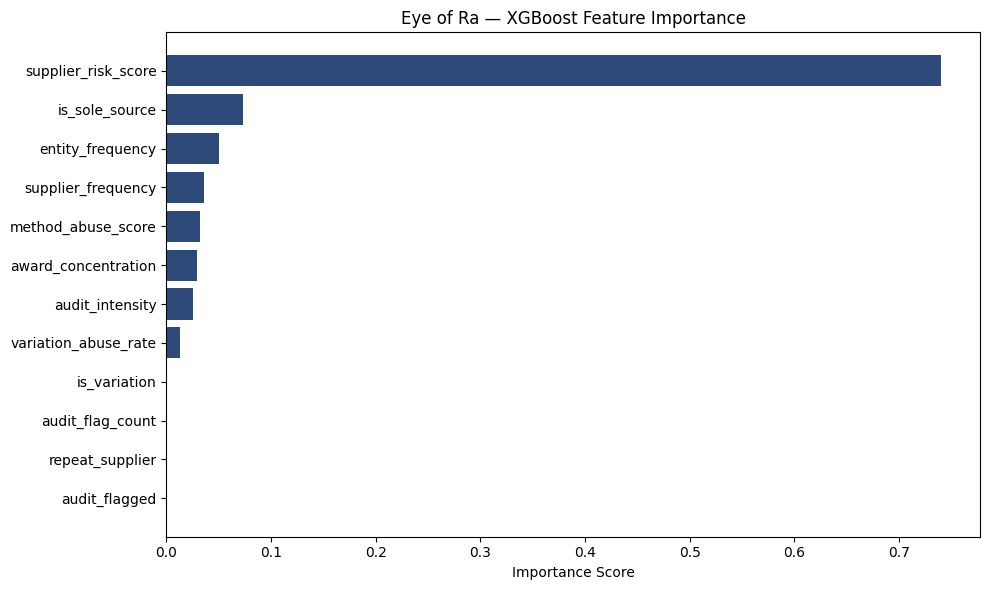


✅ Chart saved to /content/feature_importance.png


In [ ]:
# Cell 12 — Feature importance
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("=" * 50)
print("✅ FEATURE IMPORTANCE")
print("=" * 50)
print(importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'], color='#2d4a7a')
plt.xlabel('Importance Score')
plt.title('Eye of Ra — XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150)
plt.show()
print("\n✅ Chart saved to /content/feature_importance.png")

# Git: Cell 12 — feature importance analysis

In [2]:
# Cell 13 — Install SHAP
!pip install shap --quiet

import shap
print("✅ SHAP ready")

# Git: Cell 13 — install SHAP

✅ SHAP ready


In [3]:
# Cell 14 — Reload dataset and rebuild model for SHAP

df = pd.read_csv('/content/eye_of_ra_master_dataset_v3.csv')

feature_cols = [
    'is_variation',
    'is_sole_source',
    'entity_frequency',
    'supplier_frequency',
    'repeat_supplier',
    'audit_flagged',
    'audit_flag_count',
    'award_concentration',
    'method_abuse_score',
    'supplier_risk_score',
    'audit_intensity',
    'variation_abuse_rate'
]

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df['fraud_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
model.fit(X_train_sm, y_train_sm)

print("✅ Dataset loaded, model rebuilt — ready for SHAP")
print(f"X shape: {X.shape}")

# Git: Cell 14 — reload and rebuild model for SHAP session

✅ Dataset loaded, model rebuilt — ready for SHAP
X shape: (262, 12)


✅ SHAP VALUES COMPUTED
SHAP values shape: (53, 12)


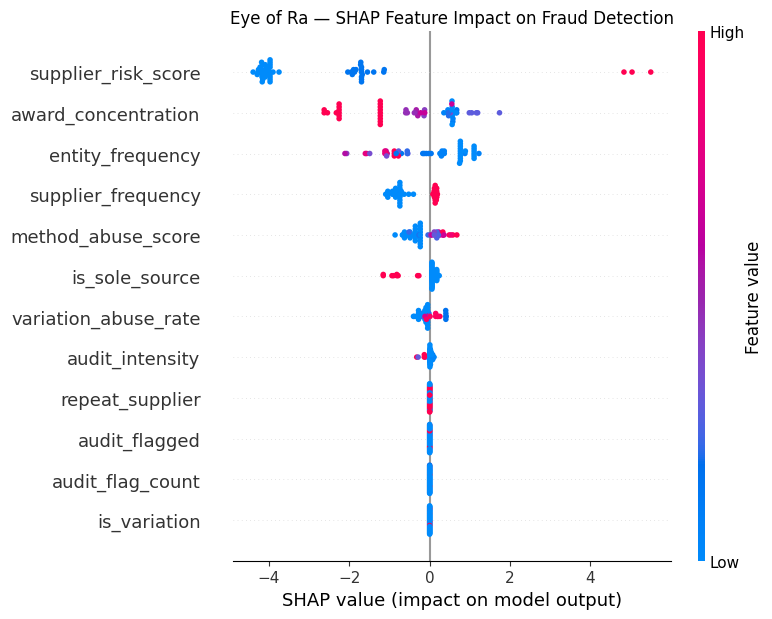


✅ SHAP summary plot saved to /content/shap_summary.png


In [4]:
# Cell 15 — SHAP explainability

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("=" * 50)
print("✅ SHAP VALUES COMPUTED")
print("=" * 50)
print(f"SHAP values shape: {shap_values.shape}")

# Summary plot — shows which features drive fraud predictions most
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title("Eye of Ra — SHAP Feature Impact on Fraud Detection")
plt.tight_layout()
plt.savefig('/content/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ SHAP summary plot saved to /content/shap_summary.png")

# Git: Cell 15 — SHAP summary plot

In [5]:
# Cell 16 — Plain English explanation for a single contract

def explain_contract(index):
    contract = X_test.iloc[index]
    shap_vals = shap_values[index]
    actual_label = y_test.iloc[index]
    predicted_proba = model.predict_proba(X_test)[index][1]

    # Pair features with their SHAP values
    explanation = pd.DataFrame({
        'feature': feature_cols,
        'value': contract.values,
        'shap_value': shap_vals
    }).sort_values('shap_value', ascending=False)

    print("=" * 55)
    print(f"CONTRACT RISK EXPLANATION")
    print("=" * 55)
    print(f"Contract index:   {index}")
    print(f"Fraud probability: {predicted_proba*100:.1f}%")
    print(f"Actual label:     {'🚨 FRAUD' if actual_label == 1 else '✅ CLEAN'}")
    print(f"\nTop reasons this contract was flagged:")

    for _, row in explanation.head(4).iterrows():
        direction = "↑ raises" if row['shap_value'] > 0 else "↓ lowers"
        print(f"  {direction} risk — {row['feature']}: {row['value']:.3f}")

    print(f"\nTop reasons working against fraud flag:")
    for _, row in explanation.tail(3).iterrows():
        print(f"  ↓ lowers risk — {row['feature']}: {row['value']:.3f}")

# Test on a fraud case from the test set
fraud_indices = [i for i, val in enumerate(y_test) if val == 1]
print(f"Fraud cases in test set: {fraud_indices}")
explain_contract(fraud_indices[0])

# Git: Cell 16 — plain English contract explanation function

Fraud cases in test set: [11, 18, 25, 37, 41]
CONTRACT RISK EXPLANATION
Contract index:   11
Fraud probability: 98.3%
Actual label:     🚨 FRAUD

Top reasons this contract was flagged:
  ↑ raises risk — supplier_risk_score: 1.000
  ↑ raises risk — entity_frequency: 2.000
  ↑ raises risk — supplier_frequency: 138.000
  ↑ raises risk — is_sole_source: 0.000

Top reasons working against fraud flag:
  ↓ lowers risk — variation_abuse_rate: 0.000
  ↓ lowers risk — method_abuse_score: 0.000
  ↓ lowers risk — award_concentration: 0.500
